In [ ]:
import pandasql as ps
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('PMC Hospital Infrastructure.csv')

In [3]:
df.head(10)

,City Name,Zone Name,Ward Name,Zone No.,Ward No.,Facility Name,Type (Hospital / Nursing Home / Lab),Class : (Public / Private),Pharmacy Available : Yes/No,Number of Beds in Emergency Wards,Number of Beds in facility type,Number of Doctors / Physicians,Number of Nurses,Number of Midwives Professional,Average Monthly Patient Footfall,Ambulance Service Available,Count of Ambulance
0,Pune,kasba - vishrambagwada WO,Ambil Odha,5.0,NaN,"Late Matoshri Ramabai Ambedkar Maternity Home,...",Hospital (Maternity Home),Public,Yes,0,10,2,4,1,4500,Yes,1
1,Pune,Aundh - Baner WO,Aundh,2.0,NaN,"Aundh Kuti Maternity Home, Aundh",Hospital (Maternity Home),Public,Yes,0,14,2,5,2,2500,Yes,1
2,Pune,Aundh - Baner WO,Bopodi,2.0,NaN,Late Draupadabai Murlidhar Khedekar Maternity ...,Hospital (Maternity Home),Public,Yes,0,16,2,4,9,1900,Yes,1
3,Pune,Ghole Road - Shivaji Nagar WO,Shivaji Nagar Station,2.0,NaN,"Dr. Dalvi, PMC Joint Project",Hospital (Maternity Home),Public,Yes,0,30,4,7,9,2400,Yes,2
4,Pune,Hadapsar - Mundhwa WO,Hadapsar,4.0,NaN,"Late Anna Saheb Magar Maternity Home, Hadapsar",Hospital (Maternity Home),Public,Yes,0,20,2,3,6,4500,Yes,1
5,Pune,Ghole Road - Shivaji Nagar WO,Health Camp,2.0,NaN,"Dr. Homi J. Bhabha Maternity Home, Health Camp",Hospital (Maternity Home),Public,Yes,0,16,2,6,6,4000,Yes,2
6,Pune,Kothrud - Bavdhan WO,"Gujrath Colony, Kothrud",2.0,NaN,"Late Jayabai Sutar Maternity Home, Kothrud",Hospital (Maternity Home),Public,Yes,0,10,4,7,6,5000,Yes,4
7,Pune,Hadapsar - Mundhwa WO,Mundhwa,4.0,NaN,"Late Sakharam Kundalik Kodre Maternity Home, M...",Hospital (Maternity Home),Public,Yes,0,8,2,6,5,3500,Yes,1
8,Pune,Aundh - Baner WO,Pashan Gaon,2.0,NaN,"Late Sahadev Eknath Nimhan Maternity Home, Pashan",Hospital (Maternity Home),Public,Yes,0,16,2,3,5,1800,Yes,1
9,Pune,Bhawani Peth WO,Bhawani Peth,5.0,NaN,Late Chandu Mama Sonawane Maternity Home,Hospital (Maternity Home),Public,Yes,0,86,5,12,9,5500,Yes,2


In [57]:
Query = """
SELECT [Zone Name], SUM([Number of beds in facility type]) as Total_Beds
FROM df
GROUP BY [Zone Name]
ORDER BY Total_Beds DESC
"""

In [58]:
result = ps.sqldf(Query, locals()) 

In [59]:
result

,Zone Name,Total_Beds
0,3,3602
1,5,3169
2,1,3148
3,2,2798
4,4,2136
5,Bhawani Peth WO,546
6,Dhole Patil Road WO,200
7,Sangamwadi WO,190
8,kasba - vishrambagwada WO,50
9,Ghole Road - Shivaji Nagar WO,46


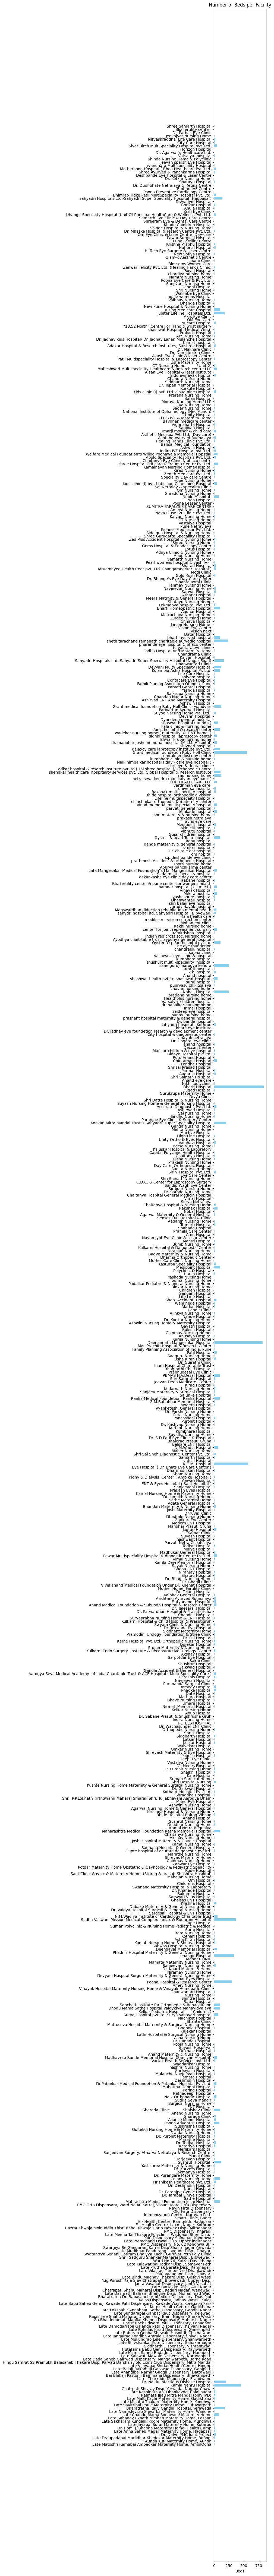

In [49]:
plt.figure(figsize=(10, 95))
plt.barh(df["Ward Name"], df["Number of Beds in facility type"], color='skyblue')
plt.xlabel("Beds")
plt.title("Number of Beds per Facility")
plt.tight_layout()
plt.show()

In [75]:
Query2 = """
SELECT "Ward Name" ,COUNT("Count Of Ambulance") as Ambulance
FROM df
GROUP BY "Ward Name"
ORDER BY "Ambulance" DESC
"""

In [76]:
result2 = ps.sqldf(Query2, locals())
result2

,Ward Name,Ambulance
0,KASBA-VISHRAM,81
1,SHIVAJINAGAR- GHOLE ROAD,74
2,HADAPSAR-MUNDHWA,59
3,SAHAKARNAGAR-DHANKWADI,55
4,KOTHRUD-BAVDHAN,54
...,...,...
76,Balaji Nagar,1
77,Aundh Road,1
78,Aundh,1
79,Atul Nagar,1


In [77]:
top_10 = result2.head(10)

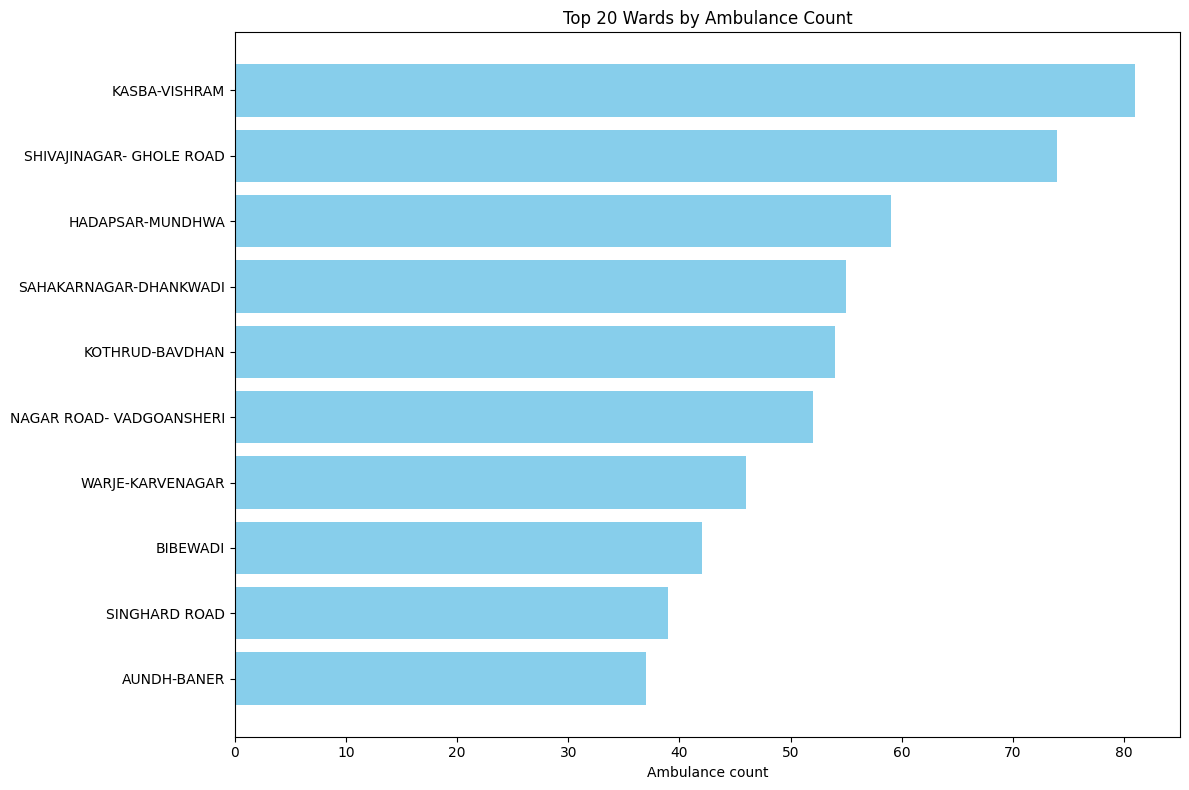

In [82]:
plt.figure(figsize=(12, 8))
plt.barh(top_10["Ward Name"][::-1], top_10["Ambulance"][::-1], color='skyblue')
plt.xlabel("Ambulance count")
plt.title("Top 20 Wards by Ambulance Count")
plt.tight_layout()
plt.show()

In [86]:
Query3 = """
SELECT AVG([Average Monthly Patient Footfall]) as Avg_Patients
FROM df
"""

In [87]:
result3 = ps.sqldf(Query3, locals())
result3

,Avg_Patients
0,247.46594


In [103]:
Query4 = """
SELECT "Facility Name", COUNT("Number of Beds in Facility Type") as TotalFB
FROM df
GROUP BY "Facility Name" 
ORDER BY TotalFB DESC
"""

In [104]:
result4 = ps.sqldf(Query4, locals())
result4

,Facility Name,TotalFB
0,Dhanwantari Hospital,4
1,Healing Hands Clinic Pvt. Ltd.,3
2,Yashwant Hospital,2
3,Yashraj Nursing Home,2
4,Vinayak Hospital,2
...,...,...
703,Aarogya Seva Medical Academy of India Charita...,1
704,Aadarsh Nursing Home,1
705,Aadarsh Hospital,1
706,APS Nursing Home,1


In [105]:
top_10 = result4.head(10)

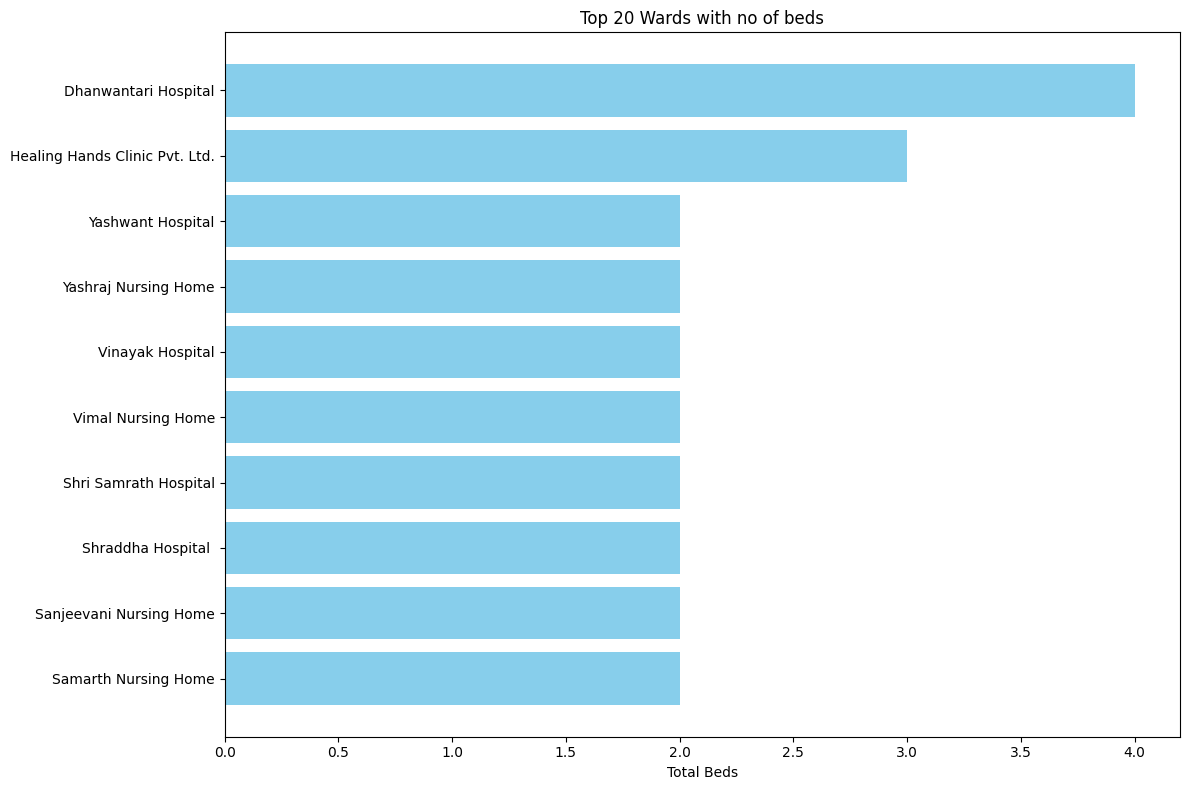

In [106]:
plt.figure(figsize=(12, 8))
plt.barh(top_10["Facility Name"][::-1], top_10["TotalFB"][::-1], color='skyblue')
plt.xlabel("Total Beds")
plt.title("Top 20 Wards with no of beds")
plt.tight_layout()
plt.show()

In [110]:
Query5 = """
SELECT "Facility Name", "Average Monthly Patient Footfall", "Count Of Ambulance"
FROM df
WHERE "Average Monthly Patient Footfall" > 2000
ORDER BY "Count of Ambulance" DESC
"""

In [111]:
result5 = ps.sqldf(Query5, locals())
result5

,Facility Name,Average Monthly Patient Footfall,Count of Ambulance
0,Mahrashtra Medical Foundation Joshi Hosptial,N.A.,N.A.
1,Sathe Hospital,N.A.,N.A.
2,Dr. Tarabai Limye Hospital,N.A.,N.A.
3,Dr. Paranjpe Gynac Hospital,N.A.,N.A.
4,Nanal Hospital,N.A.,N.A.
...,...,...,...
703,"Late Murlidhar Pandurang Laygude Disp., Dhayari",600,0
704,Swargiya Se Gangaram Karne Disp Shastrinagar Y...,700,0
705,"PMC Dispensary Sainagar, Kondhwa",300,0
706,"Hazrat Khwaja Moinuddin Khisti Rahe, Khwaja Ga...",3900,0
